# AI and Non-AI Role Demand Over Time

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)


In [4]:
from package_files.benefits_defns import *

In [5]:
# set plot fontsize to 18
plt.rcParams.update({'font.size': 14})

In [79]:
# path = '../data/even_sample.csv'

In [2]:
# data_1m = pd.read_parquet('../../data/us-003_noint.parquet')

In [4]:
pd.set_option('display.max_columns', None)

In [28]:
path = '../data/small_samples/salary_sample_2018_2023.parquet.gzip'

In [29]:
if path[-3:] == 'csv:':
    even_sample = pd.read_csv(path)
elif path[-3:] == 'zip':
    even_sample = pd.read_parquet(path)

In [16]:
even_sample.groupby('YEAR').count()

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,BODY,EDU_ASSISTANCE,WLB,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,SALARY,LOG_SALARY
YEAR,,,,,,,,,,,,,,,,,,,,,
2018,1365,1365,1365,1365,1365,1365,1365,1365,1365,1365,...,1365,1365,1365,1365,1365,1365,1365,1365,1365,1365
2019,1576,1576,1576,1576,1576,1576,1576,1576,1576,1576,...,1576,1576,1576,1576,1576,1576,1576,1576,1576,1576
2020,1984,1984,1983,1984,1984,1984,1984,1984,1984,1984,...,1984,1984,1984,1984,1984,1984,1984,1984,1984,1984
2021,3401,3401,3399,3401,3401,3401,3401,3401,3401,3401,...,3401,3401,3401,3401,3401,3401,3401,3401,3401,3401
2022,5020,5020,5016,5020,5020,5020,5020,5020,5020,5020,...,5020,5020,5020,5020,5020,5020,5020,5020,5020,5020
2023,6654,6654,6652,6654,6654,6654,6654,6654,6654,6654,...,6654,6654,6654,6654,6654,6654,6654,6654,6654,6654


In [82]:
even_sample['POSTED'] = pd.to_datetime(even_sample['POSTED'])

In [83]:
even_sample['YEARMONTH'] = even_sample['POSTED'].dt.to_period('M')

In [143]:
# even_sample.to_csv('../data/even_sample.csv', index = False)

In [13]:
monthly_postings = even_sample.groupby(['YEARMONTH', 'AI ROLE']).size().reset_index(name = 'COUNT')

In [20]:
# 2019 to 2023 because only have WHAM data for these years

In [14]:
monthly_postings

,YEARMONTH,AI ROLE,COUNT
0,2019-01,False,71
1,2019-01,True,40
2,2019-02,False,77
3,2019-02,True,34
4,2019-03,False,103
...,...,...,...
115,2023-10,True,339
116,2023-11,False,189
117,2023-11,True,366
118,2023-12,False,230


In [15]:
pivot_data = monthly_postings.pivot(index = 'YEARMONTH', columns = 'AI ROLE', values = 'COUNT').fillna(0)

In [16]:
pivot_data

AI ROLE,False,True
YEARMONTH,,
2019-01,71,40
2019-02,77,34
2019-03,103,35
2019-04,73,45
2019-05,112,43
2019-06,80,40
2019-07,79,38
2019-08,69,44
2019-09,119,52


In [17]:
pivot_data.columns = ['Other', 'AI Role']

In [19]:
baseline = pivot_data.loc['2019-01']

In [21]:
baseline

Other      71
AI Role    40
Name: 2019-01, dtype: int64

In [22]:
normalized_data = ((pivot_data - baseline) / baseline)*100

In [23]:
# normalized_data = (pivot_data/baseline)*100

In [24]:
normalized_data

,Other,AI Role
YEARMONTH,,
2019-01,0.000000,0.0
2019-02,8.450704,-15.0
2019-03,45.070423,-12.5
2019-04,2.816901,12.5
2019-05,57.746479,7.5
2019-06,12.676056,0.0
2019-07,11.267606,-5.0
2019-08,-2.816901,10.0
2019-09,67.605634,30.0


In [25]:
normalized_data.iloc[-1, 0]

223.943661971831

In [27]:
normalized_data

,Other,AI Role
YEARMONTH,,
2019-01,0.000000,0.0
2019-02,8.450704,-15.0
2019-03,45.070423,-12.5
2019-04,2.816901,12.5
2019-05,57.746479,7.5
2019-06,12.676056,0.0
2019-07,11.267606,-5.0
2019-08,-2.816901,10.0
2019-09,67.605634,30.0


In [28]:
if normalized_data.iloc[-1, 0] < -90: 
    normalized_data = normalized_data.drop(normalized_data.index[-1])

Text(0.5, 0, '')

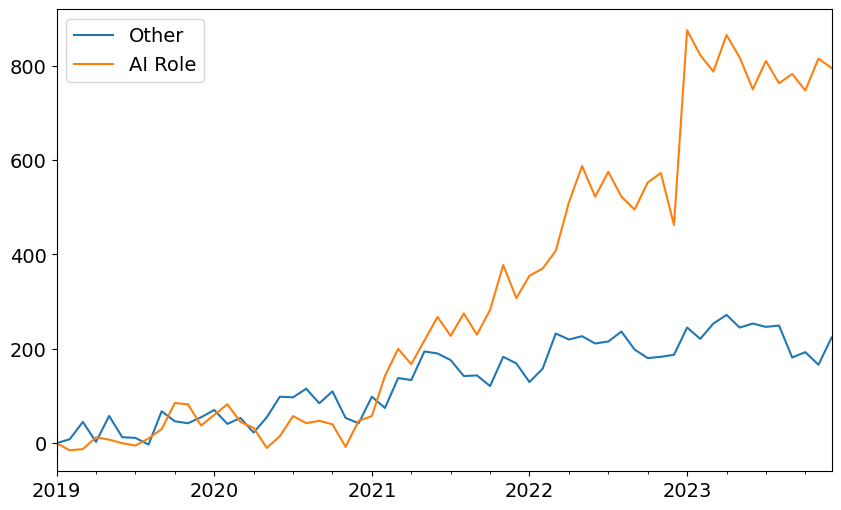

In [30]:
fig, ax = plt.subplots(figsize = (10, 6))
normalized_data.plot(ax = ax, marker = None)
# remove x axis label
plt.xlabel('')


# With Large Sample

In [1]:
path_all = '../data/us_10m_nointernship_ai_skills_benefits.parquet.gzip'

In [6]:
usdf = pd.read_parquet(path_all)

In [47]:
# usdf.rename(columns = {'HAS_AI_SKILLS': 'AI ROLE'}, inplace = True)

In [48]:
# usdf['POSTED'] = pd.to_datetime(usdf['POSTED'])

In [7]:
usdf['QUARTER'] = usdf['POSTED'].dt.to_period('Q')

In [10]:
usdf['YEARMONTH'] = usdf['POSTED'].dt.to_period('M')

AttributeError: Can only use .dt accessor with datetimelike values

In [50]:
monthly_postings = usdf.groupby(['YEARMONTH', 'AI ROLE']).size().reset_index(name = 'COUNT')

In [51]:
monthly_postings

,YEARMONTH,AI ROLE,COUNT
0,2018-01,False,7844
1,2018-01,True,103
2,2018-02,False,7354
3,2018-02,True,74
4,2018-03,False,9111
...,...,...,...
147,2024-02,True,104
148,2024-03,False,12205
149,2024-03,True,158
150,2024-04,False,94


In [52]:
pivot_data = monthly_postings.pivot(index = 'YEARMONTH', columns = 'AI ROLE', values = 'COUNT').fillna(0)

In [53]:
pivot_data

AI ROLE,False,True
YEARMONTH,,
2018-01,7844,103
2018-02,7354,74
2018-03,9111,112
2018-04,9536,104
2018-05,12619,128
...,...,...
2023-12,10334,117
2024-01,12170,149
2024-02,11384,104


In [54]:
pivot_data.columns = ['Other', 'AI Role']

In [55]:
baseline = pivot_data.loc['2019-01']

In [56]:
baseline

Other      10230
AI Role      124
Name: 2019-01, dtype: int64

In [57]:
normalized_data = ((pivot_data - baseline) / baseline)*100

In [58]:
# normalized_data = (pivot_data/baseline)*100

In [59]:
if normalized_data.iloc[-1, 0] < -90: 
    normalized_data = normalized_data.drop(normalized_data.index[-1])

In [60]:
normalized_data = normalized_data.loc['2019-01':]

Text(0.5, 0, 'Month')

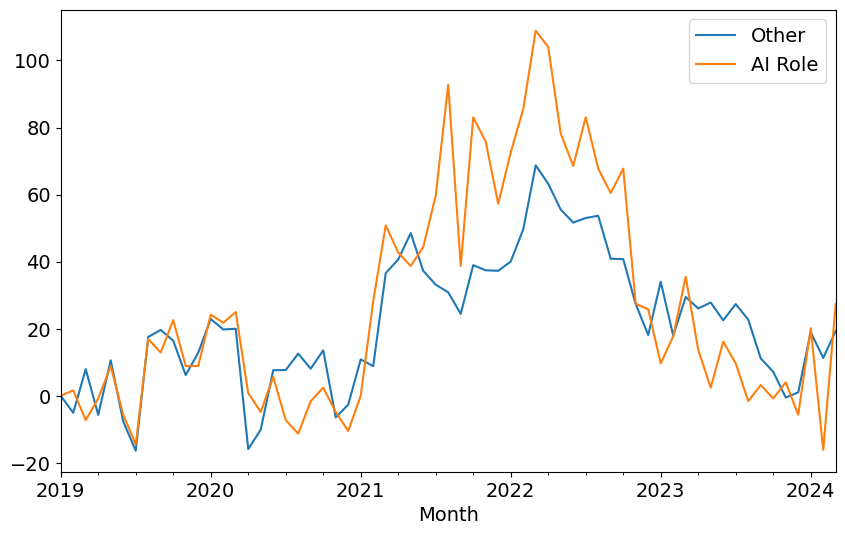

In [61]:
fig, ax = plt.subplots(figsize = (10, 6))
normalized_data.plot(ax = ax, marker = None)
ax.set_xlabel('Month')

## By Year

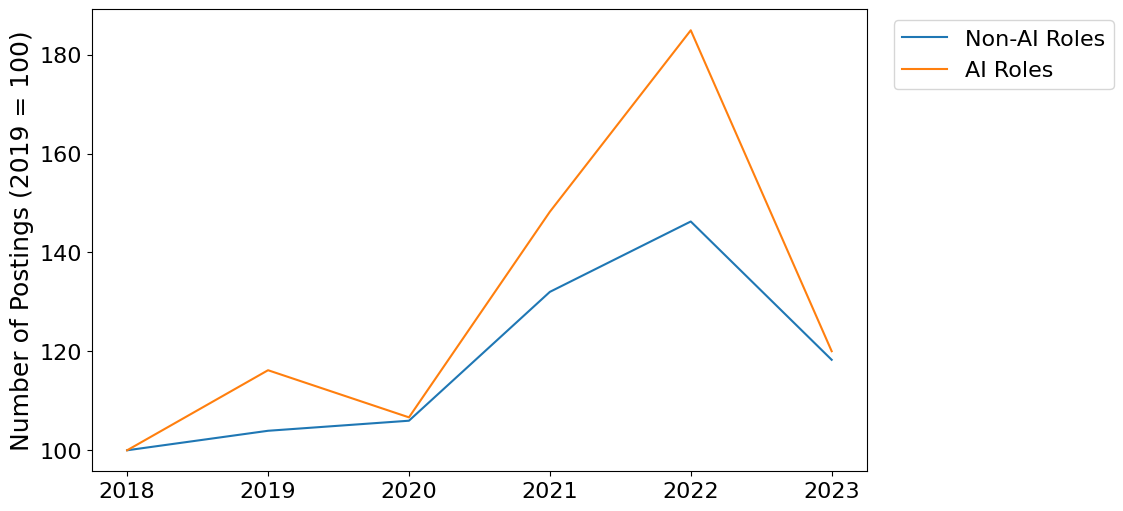

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by year and AI skills, then count the number of jobs
grouped_data = usdf.groupby(['YEAR', 'AI ROLE']).size().reset_index(name='count')

# Pivot the data to get AI skills as separate columns
pivot_data = grouped_data.pivot(index='YEAR', columns='AI ROLE', values='count').fillna(0)

# Rename the columns to "AI skills" and "Other"
pivot_data.columns = ['Other', 'AI Roles']

# Calculate the baseline (average number of postings in 2019)
baseline = pivot_data.loc[2018]

# Normalize the data
normalized_data = (pivot_data / baseline) * 100
normalized_data = normalized_data.loc[2018:2023]

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the normalized data as a time series line plot
normalized_data.plot(ax=ax, marker=None, fontsize = 16)

# Set the labels and title
ax.set_xlabel(None)
ax.set_ylabel('Number of Postings (2019 = 100)', fontsize=18)
# ax.set_title('Indexed Number of Remote Work Jobs Over Time (2019 = 100)', fontsize=16)

# Set the x-ticks to show whole years
ax.set_xticks(normalized_data.index)
ax.set_xticklabels(normalized_data.index.astype(int))

# Add a legend
ax.legend(title=None, labels = ['Non-AI Roles', 'AI Roles'], bbox_to_anchor=(1.02, 1), loc='upper left', fontsize = 16)

# Show the plot
plt.show()


In [11]:
grouped_data

,YEAR,AI ROLE,count
0,2018,False,1617510
1,2018,True,19800
2,2019,False,1681277
3,2019,True,23005
4,2020,False,1714180
5,2020,True,21118
6,2021,False,2135547
7,2021,True,29349
8,2022,False,2365724
9,2022,True,36614


In [12]:
19800/(19800 + 1617510)

0.012093006211407737

In [38]:
normalized_data

,Other,AI Roles
YEAR,,
2018,100.000000,100.000000
2019,104.258133,108.982456
2020,105.981991,107.859649
2021,131.516995,157.684211
2022,146.275655,178.385965
2023,118.398637,113.473684
2024,29.084936,28.912281


In [41]:
# filter starting from 2019
normalized_data = normalized_data.loc[2019:2023]


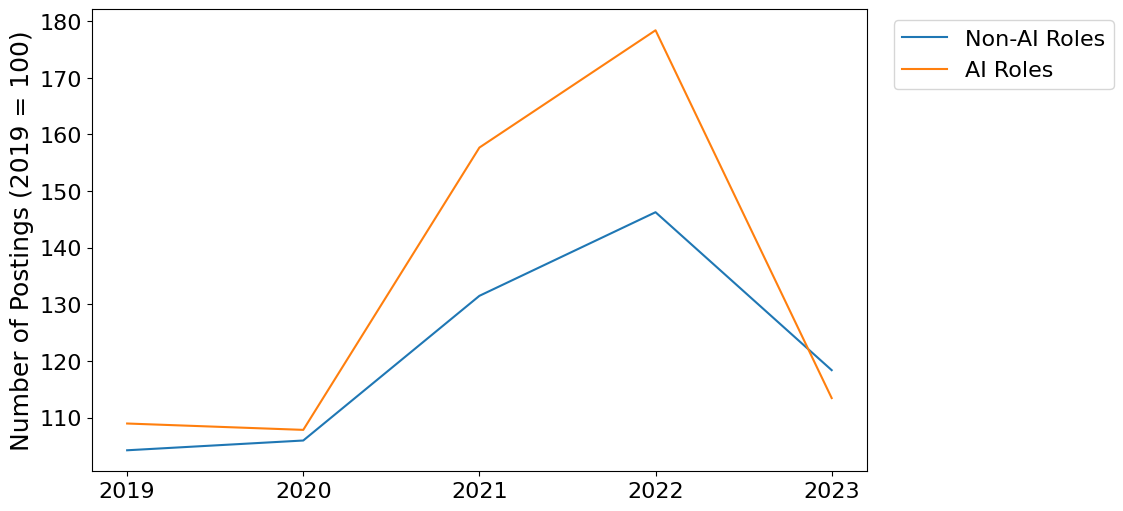

In [42]:
# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the normalized data as a time series line plot
normalized_data.plot(ax=ax, marker=None, fontsize = 16)

# Set the labels and title
ax.set_xlabel(None)
ax.set_ylabel('Number of Postings (2019 = 100)', fontsize=18)
# ax.set_title('Indexed Number of Remote Work Jobs Over Time (2019 = 100)', fontsize=16)

# Set the x-ticks to show whole years
ax.set_xticks(normalized_data.index)
ax.set_xticklabels(normalized_data.index.astype(int))

# Add a legend
ax.legend(title=None, labels = ['Non-AI Roles', 'AI Roles'], bbox_to_anchor=(1.02, 1), loc='upper left', fontsize = 16)

# Show the plot
plt.show()

# % AI Roles Over Time 

In [8]:
percent_data = usdf.groupby('QUARTER')['AI ROLE'].mean().reset_index(name = '% AI Roles')

In [9]:
# percent_data.set_index('YEAR', inplace = True)

In [10]:
percent_data['% AI Roles'] = percent_data['% AI Roles']*100

In [11]:
percent_data

,QUARTER,% AI Roles
0,2018Q1,1.233983
1,2018Q2,1.129452
2,2018Q3,1.174570
3,2018Q4,1.299070
4,2019Q1,1.337617
5,2019Q2,1.340251
6,2019Q3,1.334905
7,2019Q4,1.383649
8,2020Q1,1.296621
9,2020Q2,1.282791


In [12]:
industries = usdf[industry].unique()

In [13]:
industries

array(['Health Care and Social Assistance',
       'Accommodation and Food Services', 'Finance and Insurance',
       'Arts, Entertainment, and Recreation', 'Manufacturing',
       'Educational Services', 'Unclassified Industry',
       'Professional, Scientific, and Technical Services',
       'Public Administration', 'Transportation and Warehousing',
       'Retail Trade',
       'Administrative and Support and Waste Management and Remediation Services',
       'Real Estate and Rental and Leasing', 'Construction',
       'Other Services (except Public Administration)', 'Wholesale Trade',
       'Information', 'Management of Companies and Enterprises',
       'Agriculture, Forestry, Fishing and Hunting',
       'Mining, Quarrying, and Oil and Gas Extraction', 'Utilities'],
      dtype=object)

In [14]:
ind_dfs = []
for ind in industries:
    industry_df = usdf[usdf[industry]==ind]
    industry_pcts = industry_df.groupby('QUARTER')['AI ROLE'].mean().reset_index(name = '% AI Roles')
    ind_dfs.append(industry_pcts)

In [15]:
ind_dfs[0]

,QUARTER,% AI Roles
0,2018Q1,0.002633
1,2018Q2,0.002288
2,2018Q3,0.002520
3,2018Q4,0.001963
4,2019Q1,0.002880
5,2019Q2,0.002266
6,2019Q3,0.002262
7,2019Q4,0.002545
8,2020Q1,0.002761
9,2020Q2,0.002492


In [16]:
ind_df_all = pd.concat(ind_dfs, axis = 0)

In [17]:
ind_df_all

,QUARTER,% AI Roles
0,2018Q1,0.002633
1,2018Q2,0.002288
2,2018Q3,0.002520
3,2018Q4,0.001963
4,2019Q1,0.002880
...,...,...
19,2022Q4,0.020105
20,2023Q1,0.020358
21,2023Q2,0.018373
22,2023Q3,0.020763


In [18]:
avg_ind_year = ind_df_all.groupby('QUARTER')['% AI Roles'].mean().reset_index()

In [19]:
avg_ind_year

,QUARTER,% AI Roles
0,2018Q1,0.011377
1,2018Q2,0.010316
2,2018Q3,0.010824
3,2018Q4,0.012228
4,2019Q1,0.012486
5,2019Q2,0.012388
6,2019Q3,0.012614
7,2019Q4,0.013235
8,2020Q1,0.013074
9,2020Q2,0.013179


In [20]:
avg_ind_year.rename(columns = {'% AI Roles': 'Industry Average'}, inplace = True)

In [21]:
avg_ind_year['Industry Average'] = avg_ind_year['Industry Average']*100

In [22]:
pct_df_all = percent_data.merge(avg_ind_year, on = 'QUARTER')

In [23]:
pct_df_all

,QUARTER,% AI Roles,Industry Average
0,2018Q1,1.233983,1.137671
1,2018Q2,1.129452,1.031570
2,2018Q3,1.174570,1.082401
3,2018Q4,1.299070,1.222769
4,2019Q1,1.337617,1.248601
5,2019Q2,1.340251,1.238792
6,2019Q3,1.334905,1.261381
7,2019Q4,1.383649,1.323516
8,2020Q1,1.296621,1.307382
9,2020Q2,1.282791,1.317915


In [24]:
pct_df_all.set_index('QUARTER', inplace = True)

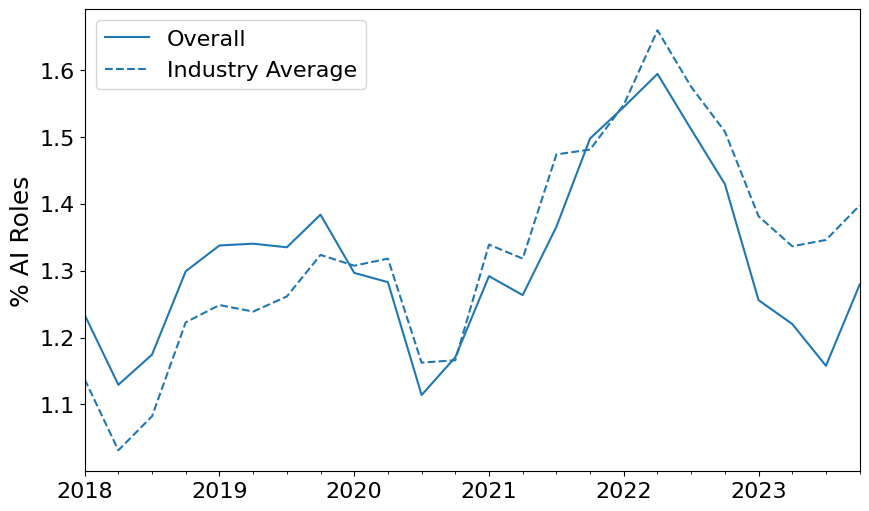

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all data
pct_df_all.plot(ax=ax, marker=None, fontsize=16)

# Set the color of the industry average line to match the '% AI Roles' line and set it as dotted
ai_roles_line = ax.lines[pct_df_all.columns.get_loc('% AI Roles')]  # Get the '% AI Roles' line
industry_avg_line = ax.lines[pct_df_all.columns.get_loc('Industry Average')]  # Get the 'Industry Average' line

industry_avg_line.set_linestyle('--')
industry_avg_line.set_color(ai_roles_line.get_color())  # Set industry average line to same color as '% AI Roles'

# Add a legend
ax.legend(title=None, labels=['Overall', 'Industry Average'], bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=16)
# Add a legend inside the plot
ax.legend(title=None, labels=['Overall', 'Industry Average'], loc='upper left', fontsize=16)
# Label adjustments
plt.xlabel(None)
plt.ylabel('% AI Roles', fontsize=18)
# plt.tight_layout()
plt.savefig('../figures/pct_ai_roles_overall_industry.png', bbox_inches = 'tight')
# Show the plot
plt.show()


# Change in Benefits Over Time

In [83]:
even_sample['POSTED'] = pd.to_datetime(even_sample['POSTED'])

In [84]:
even_sample['QUARTER'] = even_sample['POSTED'].dt.to_period('Q')

In [86]:
benefits_labels

('Tuition Assistance',
 'Work-Life Balance',
 'Paid Vacation',
 'Health & Wellbeing',
 'Parental Leave',
 'Inclusive Culture',
 'Remote Work')

In [87]:
# map benefits to benefits labels
benefit_labels_map = {}
for i, benefit in enumerate(benefits):
    benefit_labels_map[benefit] = benefits_labels[i]

In [88]:
benefit_labels_map

{'EDU_ASSISTANCE': 'Tuition Assistance',
 'WLB': 'Work-Life Balance',
 'PAID_LEAVE': 'Paid Vacation',
 'HEALTH_WELLBEING': 'Health & Wellbeing',
 'PARENTAL_LEAVE': 'Parental Leave',
 'CULTURE': 'Inclusive Culture',
 'wfh_wham': 'Remote Work'}

In [92]:
def count_benefits(data, benefit, period):
    """
    Plot the benefits for AI and non AI roles over time.

    Parameters:
    - data: a DataFrame containing the benefits of remote work over time
    - benefit: the benefit to plot

    Returns:
    - None
    """
    
    grouped_data = data.groupby([period, 'AI ROLE', benefit]).size().reset_index(name='count')


    # Calculate the total number of jobs per month for each AI skill category
    total_monthly_jobs = grouped_data.groupby([period, 'AI ROLE'])['count'].sum().reset_index(name='total_count')

    # Filter for benefit
    benefit_jobs = grouped_data[grouped_data[benefit] == 1]
    benefit_monthly_jobs = benefit_jobs.groupby([period, 'AI ROLE'])['count'].sum().reset_index(name='benefit_count')

    # Merge the total monthly jobs with the remote jobs data
    merged_data = pd.merge(benefit_monthly_jobs, total_monthly_jobs, on=[period, 'AI ROLE'])
    merged_data['percentage'] = (merged_data['benefit_count'] / merged_data['total_count']) * 100
    # display(merged_data)
    return merged_data



def plot_benefits(merged_data, benefit, period):
    pivot_data = merged_data.pivot(index = period, columns = 'AI ROLE', values = 'percentage').fillna(0)
    # Create a figure and axis object
    fig, ax = plt.subplots(figsize=(10, 6))

    pivot_data.plot(ax = ax)
    ax.set_xlabel(None)
    ax.set_ylabel('Percent Jobs with Benefit')
    ax.legend(['Other', 'AI Role'])
    ax.set_title(benefit_labels_map[benefit])
    ax.set_ylim(0, 50)
    plt.savefig(f'../figures/over_time_{benefit}_2.png')
 
    # Show the plot
    plt.show()

In [90]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,WELLBEING,HEALTH_WELLBEING,RECOGNITION,FAMILY,PARENTAL_LEAVE,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY,YEARMONTH,QUARTER
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,True,3-5 years,12.177416,2023-03,2023Q1
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,...,False,True,False,False,False,False,6-10 years,11.813585,2022-08,2022Q3
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,None Listed,11.169900,2022-05,2022Q2
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,11.670356,2022-10,2022Q4
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,1-2 years,11.407565,2019-09,2019Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,None Listed,10.635855,2021-03,2021Q1
19996,47eead071d7aa1bb7f3e11e10476688deb22e324,"Lithia Springs, GA","Douglas, GA",Georgia,56,Administrative and Support and Waste Managemen...,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,3-5 years,10.551899,2021-08,2021Q3
19997,20de39afaee660a555b7d99e8142f5f3906f0a29,"Lufkin, TX","Angelina, TX",Texas,44,Retail Trade,No Education Listed,3,Part-time / full-time,False,...,True,True,False,True,True,False,None Listed,10.097573,2021-06,2021Q2
19998,561636d55907d615dcdb24a4ae8fd2777829e767,"Scottsdale, AZ","Maricopa, AZ",Arizona,72,Accommodation and Food Services,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,1-2 years,10.544288,2022-03,2022Q1


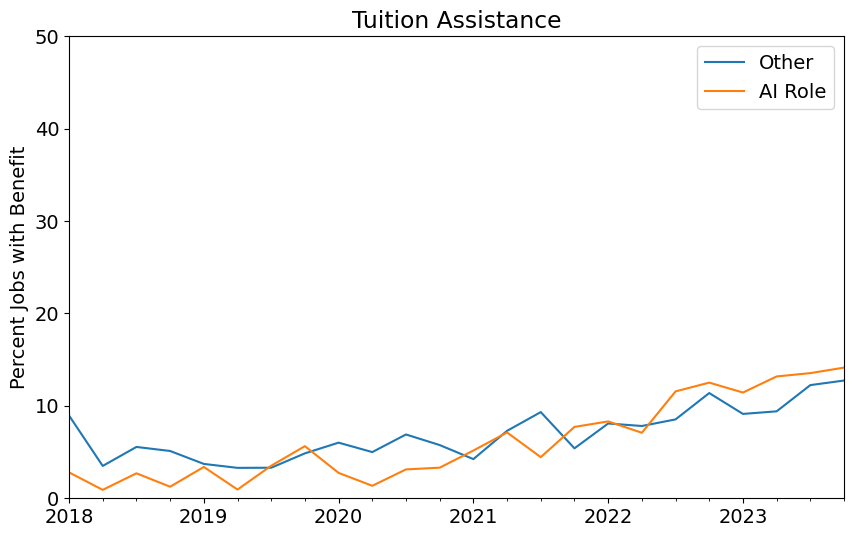

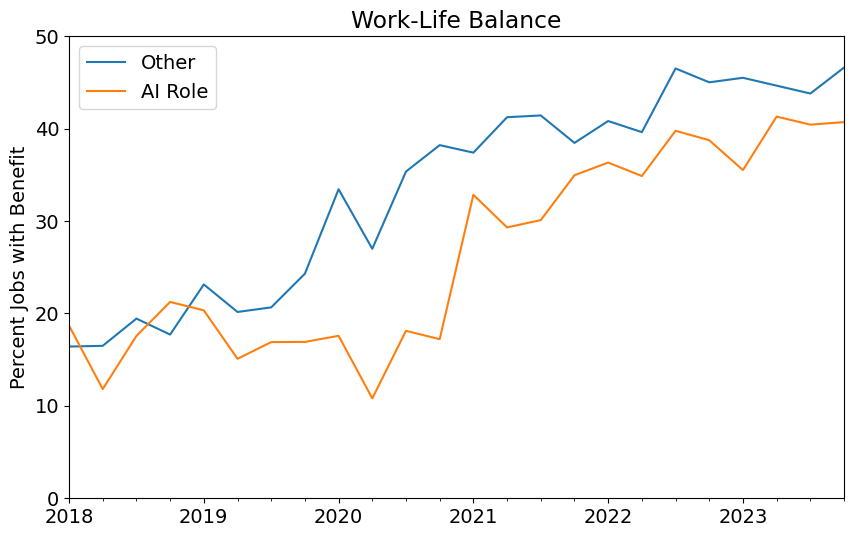

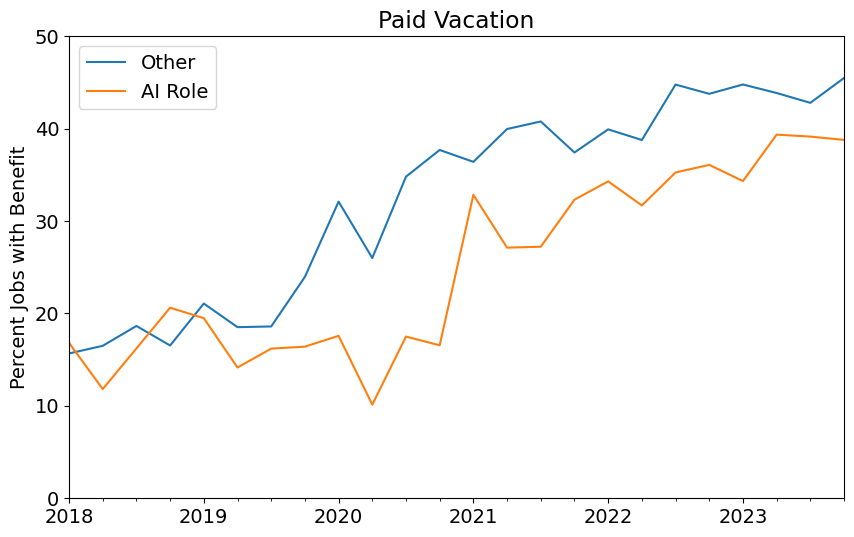

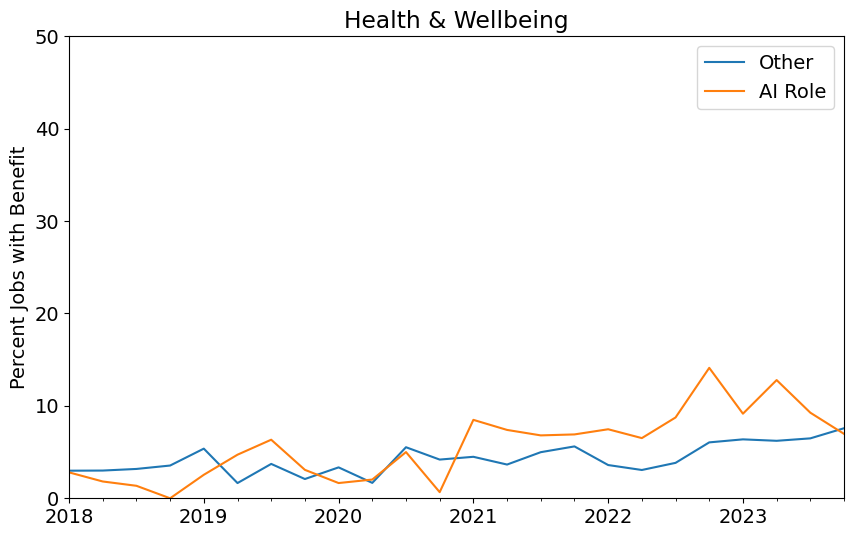

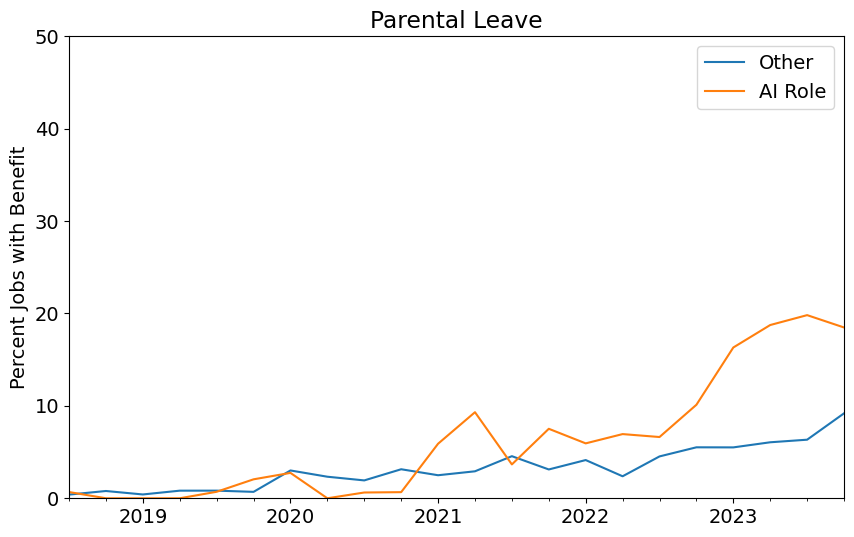

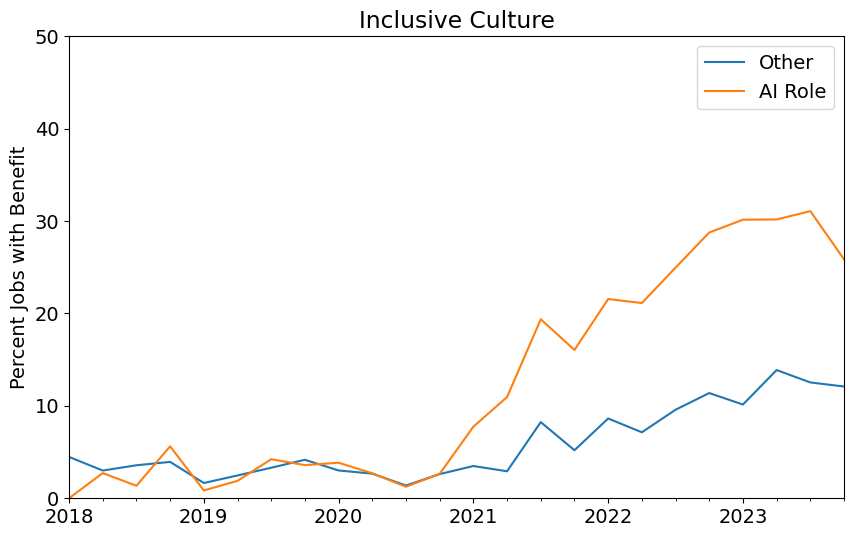

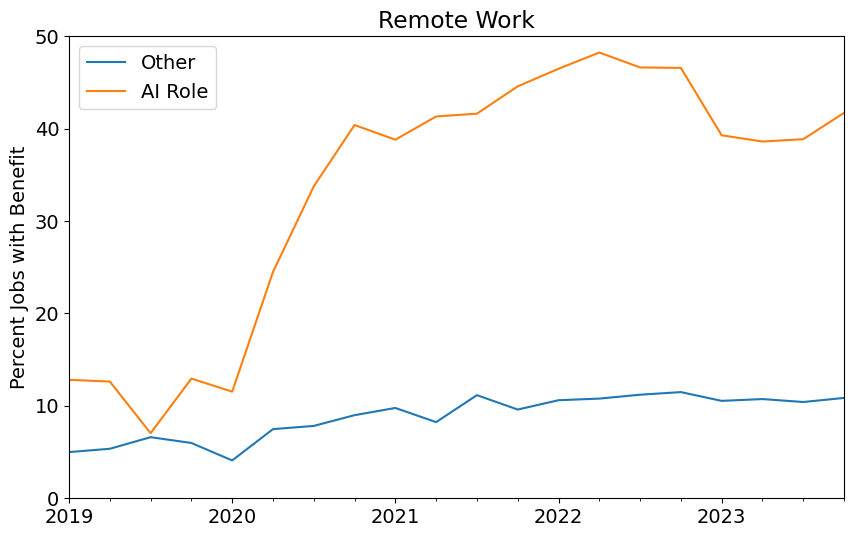

In [93]:
for benefit in benefits:
    merged_data = count_benefits(even_sample, benefit, 'QUARTER')
    plot_benefits(merged_data, benefit, 'QUARTER')

In [ ]:


# Convert 'POSTED' column to datetime
usdf['POSTED'] = pd.to_datetime(usdf['POSTED'])

# Group by date and AI skills, then count the number of jobs
grouped_data = usdf.groupby(['POSTED', 'Has AI Skills', 'wfh_wham']).size().reset_index(name='count')

# Resample by month
grouped_data['POSTED'] = grouped_data['POSTED'].dt.to_period('M')

# Calculate the total number of jobs per month for each AI skill category
total_monthly_jobs = grouped_data.groupby(['POSTED', 'Has AI Skills'])['count'].sum().reset_index(name='total_count')

# Filter for remote work jobs
remote_jobs = grouped_data[grouped_data['wfh_wham'] == 1]
remote_monthly_jobs = remote_jobs.groupby(['POSTED', 'Has AI Skills'])['count'].sum().reset_index(name='remote_count')

# Merge the total monthly jobs with the remote jobs data
merged_data = pd.merge(remote_monthly_jobs, total_monthly_jobs, on=['POSTED', 'Has AI Skills'])





In [ ]:

# Calculate the percentage of remote jobs for each AI skills category per month
merged_data['percentage'] = (merged_data['remote_count'] / merged_data['total_count']) * 100

# Convert 'POSTED' back to datetime for plotting
merged_data['POSTED'] = merged_data['POSTED'].dt.to_timestamp()

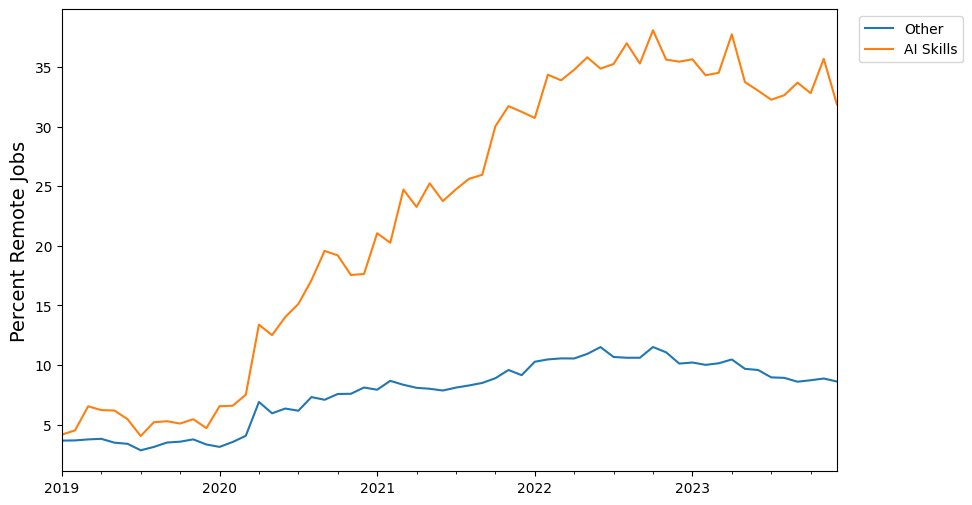

In [ ]:
# Pivot the data to get AI skills as separate columns for percentages
pivot_data = merged_data.pivot(index='POSTED', columns='Has AI Skills', values='percentage').fillna(0)

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data as a time series line plot
pivot_data.plot(ax=ax)

# Set the labels and title
ax.set_xlabel(None)
ax.set_ylabel('Percent Remote Jobs', fontsize=14)
# ax.set_title('Percentage of Remote Work Jobs Over Time', fontsize=16)

# Add a legend
ax.legend(['Other','AI Skills'], bbox_to_anchor=(1.02, 1), loc='upper left')

# Show the plot
plt.show()

# Benefits by Company

CAREER_DEV


,COMPANY_RAW,0
0,Jobot,94
1,Guidehouse,93
2,Unknown,80
3,AT&T,38
4,General Motors,34
5,CVS Health,32
6,UnitedHealth Group,30
7,Deloitte,27
8,Lincoln Financial Group,26
9,Booz Allen Hamilton,26


WLB


,COMPANY_RAW,0
0,Unknown,170
1,Jobot,139
2,USAA,98
3,Guidehouse,91
4,CyberCoders,79
5,Elevance Health,51
6,Northrop Grumman,46
7,"Anthem, Inc.",41
8,Amazon,38
9,AT&T,38


WELLBEING


...

,COMPANY_RAW,0
0,Randstad,49
1,General Motors,33
2,"Randstad North America, Inc.",32
3,Randstad US,25
4,Randstad Technologies,17
5,Hudson Group,9
6,Randstad USA,9
7,BAE Systems,8
8,AECOM,6
9,"Spherion Staffing, LLC",4


FAMILY


,COMPANY_RAW,0
0,Guidehouse,92
1,Unknown,36
2,General Motors,33
3,Lincoln Financial Group,26
4,Oracle,26
5,Marriott,23
6,TheCollegeBoard,21
7,Jobot,19
8,TikTok,18
9,Cox,18


CULTURE


,COMPANY_RAW,0
0,Capital One,143
1,Accenture,140
2,Elevance Health,51
3,UnitedHealth Group,45
4,Unknown,34
5,Pearson,32
6,Lincoln Financial Group,29
7,Oracle,24
8,Deloitte,24
9,General Motors,22


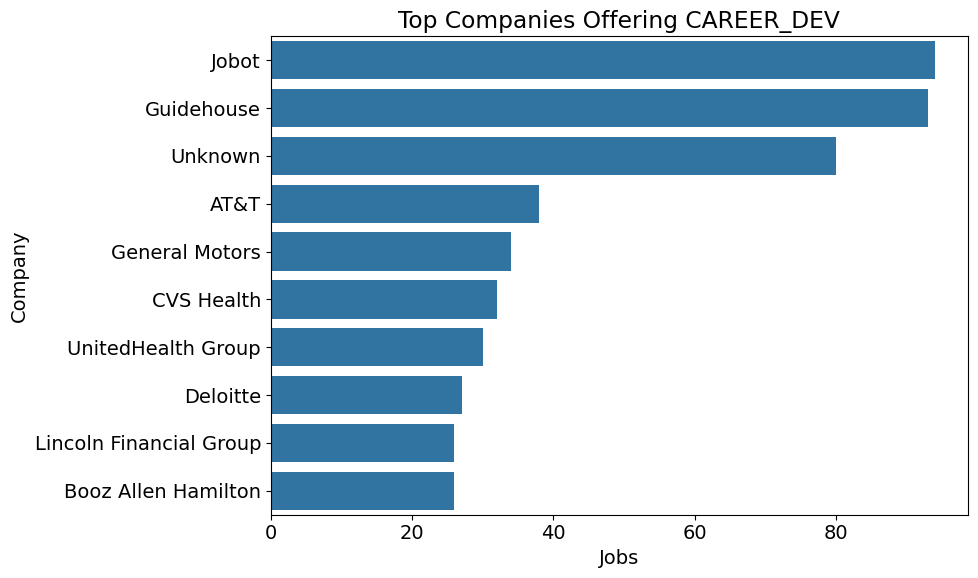

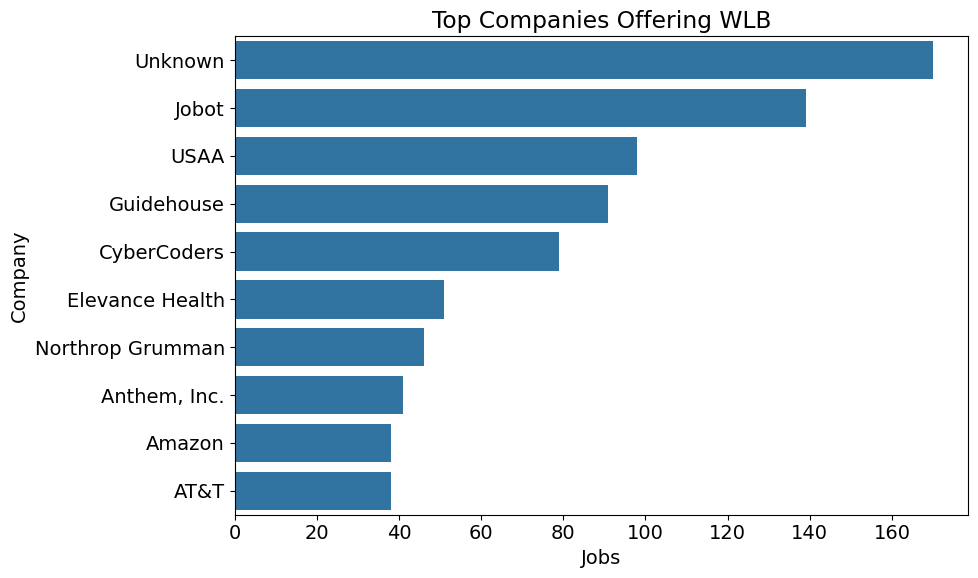

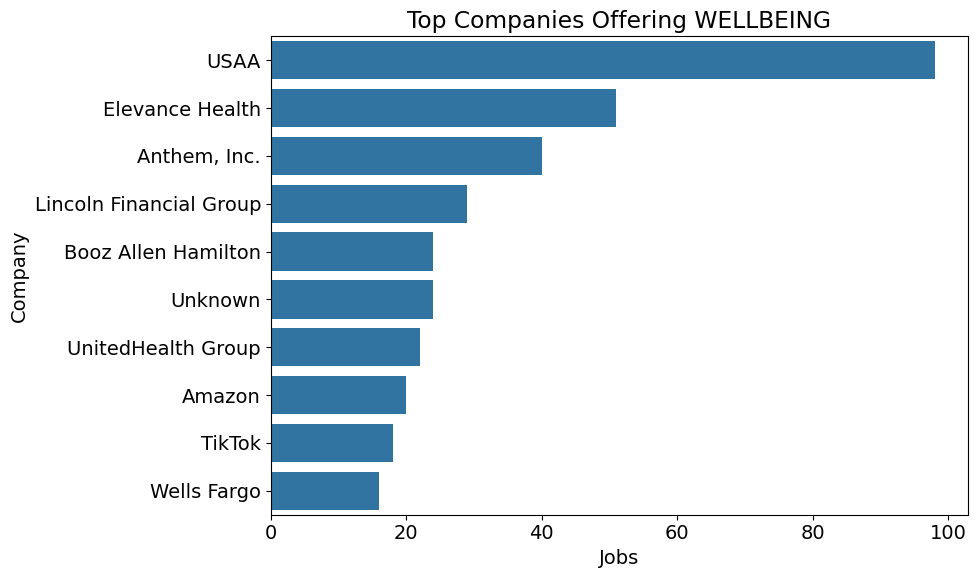

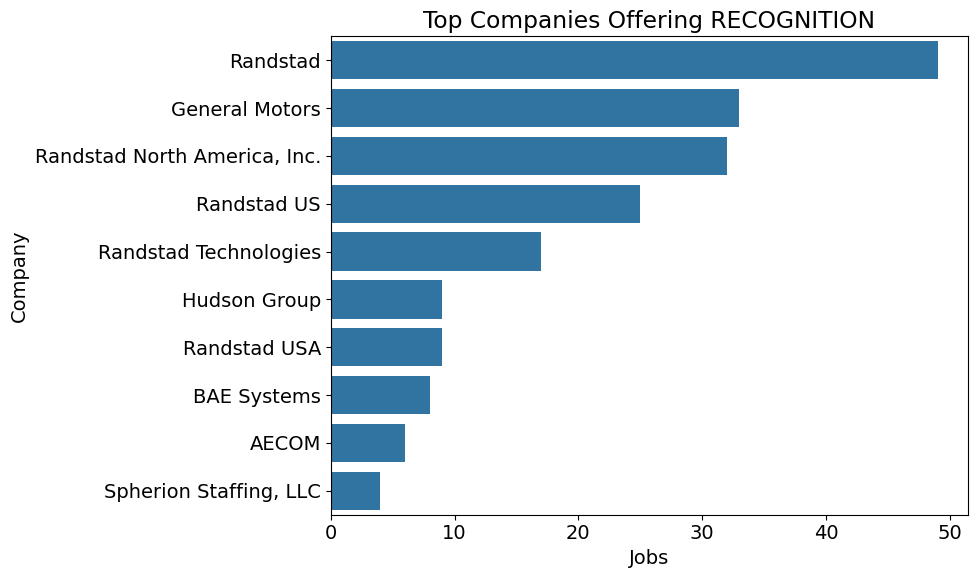

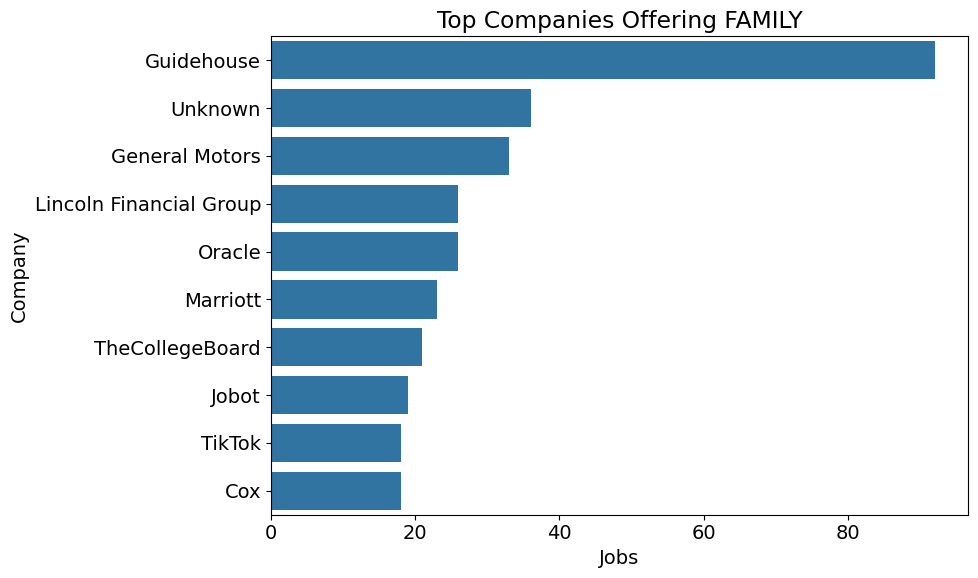

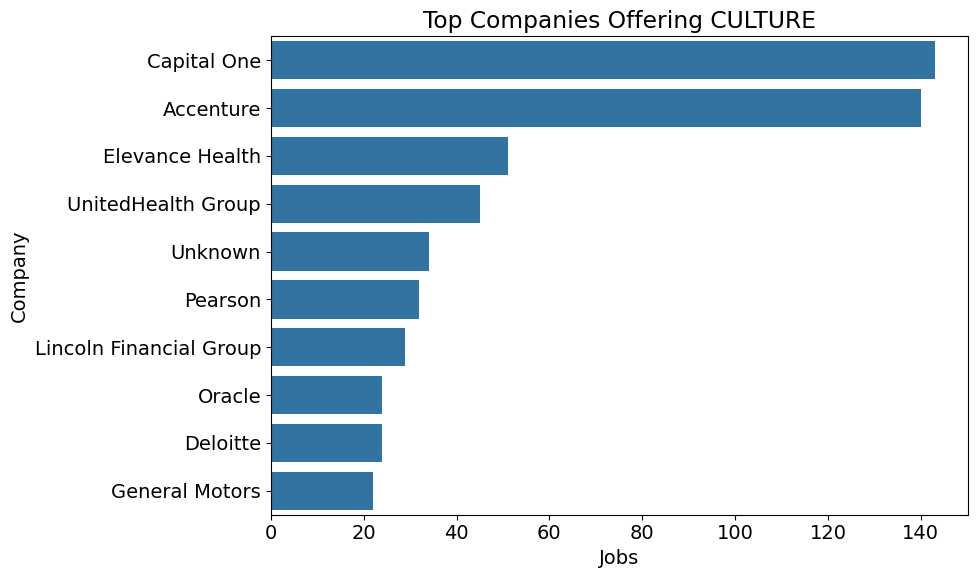

In [174]:
for benefit in benefits:
    benefit_df = even_sample[even_sample[benefit] == True]
    company_count = benefit_df.groupby('COMPANY_RAW').size().sort_values(ascending=False).reset_index()
    # plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=0, y='COMPANY_RAW', data=company_count.head(10))
    plt.xlabel('Jobs')
    plt.ylabel('Company')
    
    plt.title(f'Top Companies Offering {benefit}')
    plt.tight_layout()
    plt.savefig(f'../figures/{benefit}_companies_salary.png')
    print(benefit)
    display(company_count.head(10))

# Benefits by Company and AI Skills

In [176]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,BLS_NAICS,BLS_industry,CAREER_DEV,WLB,WELLBEING,RECOGNITION,FAMILY,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,31.0,Manufacturing,False,False,False,False,False,True,3-5 years,12.177416
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,...,54.0,Professional and business services,False,True,True,False,False,False,6-10 years,11.813585
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,...,44.0,Retail trade,False,True,False,False,False,False,None Listed,11.169900
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,...,53.0,Financial activities,False,False,False,False,False,False,3-5 years,11.670356
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,51.0,Information,False,False,False,False,False,False,1-2 years,11.407565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,...,52.0,Financial activities,False,True,False,False,False,False,None Listed,10.635855
19996,47eead071d7aa1bb7f3e11e10476688deb22e324,"Lithia Springs, GA","Douglas, GA",Georgia,56,Administrative and Support and Waste Managemen...,No Education Listed,1,Full-time (> 32 hours),False,...,56.0,Professional and business services,False,False,False,False,False,False,3-5 years,10.551899
19997,20de39afaee660a555b7d99e8142f5f3906f0a29,"Lufkin, TX","Angelina, TX",Texas,44,Retail Trade,No Education Listed,3,Part-time / full-time,False,...,44.0,Retail trade,True,True,True,False,True,False,None Listed,10.097573
19998,561636d55907d615dcdb24a4ae8fd2777829e767,"Scottsdale, AZ","Maricopa, AZ",Arizona,72,Accommodation and Food Services,No Education Listed,1,Full-time (> 32 hours),False,...,72.0,Leisure and hospitality,True,False,False,False,False,False,1-2 years,10.544288


In [180]:
pd.set_option('display.max_columns', None)

In [181]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,AI ROLE,wfh_wham_prob,wfh_wham,YEAR,SALARY,BODY,BLS_NAICS,BLS_industry,CAREER_DEV,WLB,WELLBEING,RECOGNITION,FAMILY,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS1200364C9C1LK3V5Q1"",\n ""KS1219W70LY1G...","[\n ""C (Programming Language)"",\n ""C++ (Prog...",2023-03-05,2024-03-26,15-2051.00,Data Scientists,15-2051.00,Data Scientists,Computer and Mathematical Occupations,15-0000,5.0,40227665,Viasat,Viasat,True,0.240,0.0,2023,194350.0,Machine Learning Engineer\n Viasat\n\n United ...,31.0,Manufacturing,False,False,False,False,False,True,3-5 years,12.177416
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS126L563YF9Y...","[\n ""Power BI"",\n ""Milestones (Project Manag...",2022-08-18,2024-04-19,13-1111.00,Management Analysts,13-1111.00,Management Analysts,Business and Financial Operations Occupations,13-0000,7.0,5732448,Deloitte,Deloitte,True,0.006,0.0,2022,135075.0,"Manager, People Analytics Deloitte - 3.9 Memph...",54.0,Professional and business services,False,True,True,False,False,False,6-10 years,11.813585
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS441726FF2HB...","[\n ""Power BI"",\n ""Target Audience"",\n ""Man...",2022-05-27,2024-04-19,15-2051.01,Business Intelligence Analysts,15-2051.01,Business Intelligence Analysts,Computer and Mathematical Occupations,15-0000,NaN,43639907,Dentsu,dentsu,True,0.002,0.0,2022,70962.0,"Careers in Analytics dentsu - 4.3 Detroit, MI ...",44.0,Retail trade,False,True,False,False,False,False,None Listed,11.169900
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,1,Remote,"[\n ""KS122CH79G2KSBRRJHTN"",\n ""KS123HX69V95S...","[\n ""Contract Management"",\n ""Performance Ap...",2022-10-27,2024-03-26,11-3061.00,Purchasing Managers,11-3061.00,Purchasing Managers,Management Occupations,11-0000,5.0,6213303,CBRE,CBRE,True,0.959,1.0,2022,117050.0,JOB DETAILS\n\nJob Details\nProcurement Manage...,53.0,Financial activities,False,False,False,False,False,False,3-5 years,11.670356
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""ES4B99FD0FD70AC92985"",\n ""KS126L563YF9Y...","[\n ""Infrastructure Architecture"",\n ""Milest...",2019-09-16,2024-04-19,15-1251.00,Computer Programmers,15-1251.00,Computer Programmers,Computer and Mathematical Occupations,15-0000,2.0,34817379,Mobile Apps Company,Mobile Apps Company,True,0.043,0.0,2019,90000.0,Posted on\n\nEntry Level Software Programmer\n...,51.0,Information,False,False,False,False,False,False,1-2 years,11.407565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121CT6DCXTRKRJF4RV"",\n ""KS1256K6CCY9P...","[\n ""Capital Requirements"",\n ""Insurance Pro...",2021-03-08,2023-12-14,41-3021.00,Insurance Sales Agents,41-3021.00,Insurance Sales Agents,Sal

In [190]:
for benefit in benefits:
    print(benefit)
    companies_with_benefit = even_sample[even_sample[benefit] == True]['COMPANY_NAME'].unique()
    filtered = even_sample[even_sample['COMPANY_NAME'].isin(companies_with_benefit)]
    display(filtered.groupby(['COMPANY_NAME','AI ROLE',benefit]).size().sort_values())

CAREER_DEV


COMPANY_NAME                   AI ROLE  CAREER_DEV
(Im)Prove                      True     False            1
Noom                           True     True             1
North Dakota State University  True     False            1
                                        True             1
North Wind Group               False    True             1
                                                      ... 
Unclassified                   False    True           242
                               True     True           247
Randstad                       True     False          327
Unclassified                   True     False          666
                               False    False         1231
Length: 2939, dtype: int64

WLB


COMPANY_NAME             AI ROLE  WLB  
#Twiceasnice Recruiting  False    False      1
Okaya                    True     True       1
Okta                     True     False      1
                                  True       1
Old Navy                 False    True       1
                                          ... 
Randstad                 True     False    333
Unclassified             True     True     341
                         False    True     486
                         True     False    572
                         False    False    987
Length: 4566, dtype: int64

WELLBEING


...

COMPANY_NAME             AI ROLE  RECOGNITION
3D Systems               True     True              1
Penske Automotive Group  False    True              1
Owens Corning            True     True              1
                                  False             1
Olmsted County           False    True              1
                                                 ... 
Randstad                 True     True            103
                         False    False           108
                         True     False           236
Unclassified             True     False           910
                         False    False          1462
Length: 146, dtype: int64

FAMILY


COMPANY_NAME                         AI ROLE  FAMILY
1Life Healthcare                     True     True         1
Open Minds Child Development Center  False    True         1
Openlane                             False    True         1
Oracle                               False    False        1
Oregon State University              True     True         1
                                                        ... 
Amazon                               False    False      143
CyberCoders                          True     False      172
Randstad                             True     False      337
Unclassified                         True     False      829
                                     False    False     1416
Length: 1025, dtype: int64

CULTURE


COMPANY_NAME                                              AI ROLE  CULTURE
2020 Companies                                            False    True          1
NYU                                                       False    True          1
NYU Langone Health                                        False    True          1
National Association of County and City Health Officials  True     True          1
National Grid                                             True     True          1
                                                                              ... 
Capital One                                               True     True        150
CyberCoders                                               True     False       171
Randstad                                                  True     False       332
Unclassified                                              True     False       858
                                                          False    False      1431
Length: 1250

# Percent Jobs Offering Benefits per Role Type

In [53]:

# Calculate percentages for each benefit by HAS_AI_SKILLS
percentages = even_sample.groupby('AI ROLE')[benefits4].mean() * 100

In [54]:
percentages

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,wfh_wham
AI ROLE,,,,,,
False,7.81,36.46,4.67,3.78,7.14,9.501713
True,9.43,31.99,7.97,10.58,21.07,39.601746


In [41]:
for attribute, value in percentages.iterrows():
    print(benefit_colors.get(attribute))

None
None


In [55]:
benefit_colors = {
    'EDU_ASSISTANCE': '#41afaa',
    'PAID_LEAVE': '#466eb4',
    'HEALTH_WELLBEING': '#e6a532',
    'PARENTAL_LEAVE': '#00a0e1',
    'CULTURE': '#d7642c',
    'wfh_wham': '#af4b91'
}

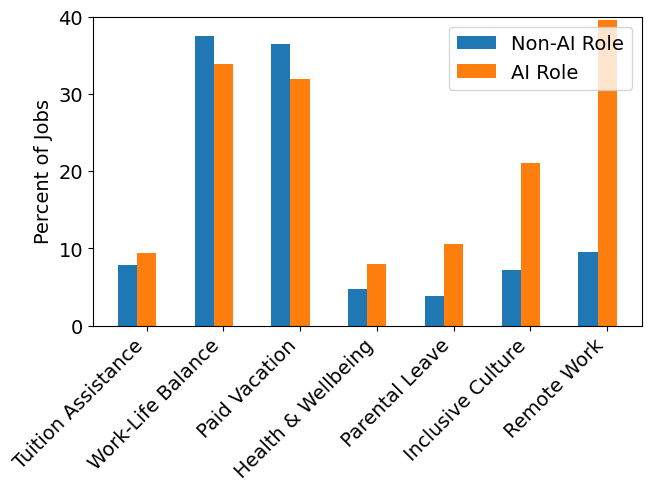

In [75]:
x = np.arange(len(benefits))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout = 'constrained')
for attribute, value in percentages.iterrows():
    color = benefit_colors.get(attribute)
    alpha = 0.7 if False in attribute else 1.0 
    ax.bar(x + width*multiplier, value, width, label=attribute, color=color, alpha=alpha)
    multiplier += 1
    
ax.set_ylabel('Percent of Jobs')
ax.set_xticks(x+width, benefits4_labels, rotation=45, ha = 'right')
# set ylim
ax.set_ylim(0, 40)
ax.legend(loc = 'upper right', ncols = 2)
# change legend labels
ax.legend(['Non-AI Role', 'AI Role'])



In [47]:
len(x)

6

In [48]:
len(benefits4)

6

In [52]:
percentages

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,wfh_wham,wfh_wham
AI ROLE,,,,,,,
False,7.81,36.46,4.67,3.78,7.14,9.501713,9.501713
True,9.43,31.99,7.97,10.58,21.07,39.601746,39.601746


In [61]:
# put True row before False in percentages
percentages = percentages.reindex([True, False])

In [65]:
percentages

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,wfh_wham
AI ROLE,,,,,,
True,9.43,31.99,7.97,10.58,21.07,39.601746
False,7.81,36.46,4.67,3.78,7.14,9.501713


In [67]:
for i, (role, row) in enumerate(percentages.iterrows()):
    if role == False:
        print("alpha 0.7")

alpha 0.7


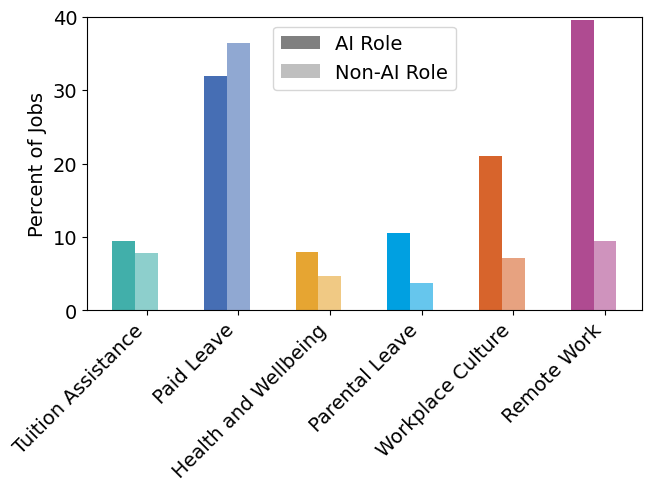

In [75]:
x = np.arange(len(benefits4))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout = 'constrained')
for i, (role, row) in enumerate(percentages.iterrows()):
    color = [benefit_colors[benefit] for benefit in benefits4]
    alpha = 0.6 if role == False else 1.0
    ax.bar(x + i * width, row[benefits4], width, label=f'AI Role: {role}', color=color, alpha = alpha)
    
ax.set_ylabel('Percent of Jobs')
ax.set_xticks(x+width, benefits4_labels, rotation=45, ha = 'right')
# set ylim
ax.set_ylim(0, 40)
ax.legend(loc = 'upper right', ncols = 2)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', alpha=1.0, label='AI Role'),
    Patch(facecolor='gray', alpha=0.5, label='Non-AI Role')
]
ax.legend(handles=legend_elements, title=None)
# change legend labels
# ax.legend(['AI Role', 'Non-AI Role'])
plt.savefig('../figures/pct jobs by benefit and role type/benefits_ai_role_colors.png', bbox_inches = 'tight')



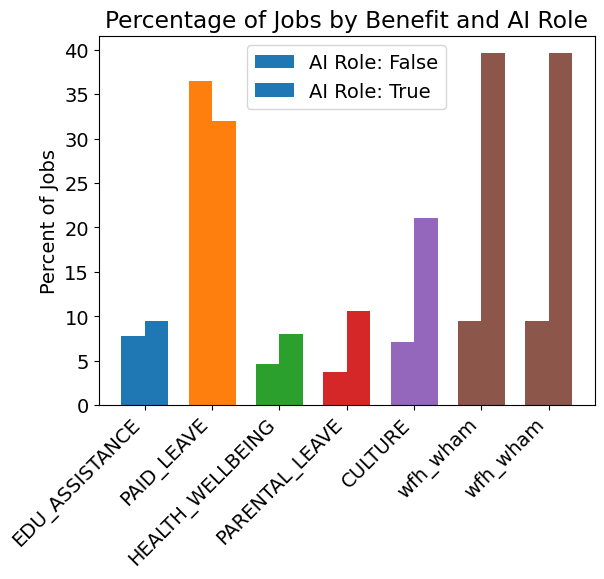

In [42]:
benefit_colors = {
    'EDU_ASSISTANCE': '#1f77b4',  # Blue
    'PAID_LEAVE': '#ff7f0e',      # Orange
    'HEALTH_WELLBEING': '#2ca02c',# Green
    'PARENTAL_LEAVE': '#d62728',  # Red
    'CULTURE': '#9467bd',         # Purple
    'wfh_wham': '#8c564b'         # Brown
}

# Assuming percentages is your DataFrame
x = np.arange(len(benefits))
width = 0.35

fig, ax = plt.subplots()
for i, (role, row) in enumerate(percentages.iterrows()):
    color = [benefit_colors[benefit] for benefit in benefits]
    ax.bar(x + i * width, row, width, label=f'AI Role: {role}', color=color)

ax.set_ylabel('Percent of Jobs')
ax.set_title('Percentage of Jobs by Benefit and AI Role')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(benefits, rotation=45, ha='right')
ax.legend()

plt.show()

## WHAM Sample

In [52]:
wham_even_sample = pd.read_parquet('../data/small_samples/salary_wham_sample_20k.parquet.gzip')

In [53]:
benefits = benefits4+['wfh_wham']

In [68]:

# Calculate percentages for each benefit by HAS_AI_SKILLS
percentages = wham_even_sample.groupby('AI ROLE')[benefits].mean() * 100

In [69]:
percentages

,EDU_ASSISTANCE,WLB,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,wfh_wham
AI ROLE,,,,,,,
False,7.76,38.15,37.20,5.39,3.97,7.84,9.57
True,9.90,34.63,32.75,8.66,10.92,22.13,38.45


In [70]:
benefits_labels = "Tuition Assistance", "Work-Life Balance", "Paid Vacation", "Health & Wellbeing", "Parental Leave", "Inclusive Culture", "Remote Work"

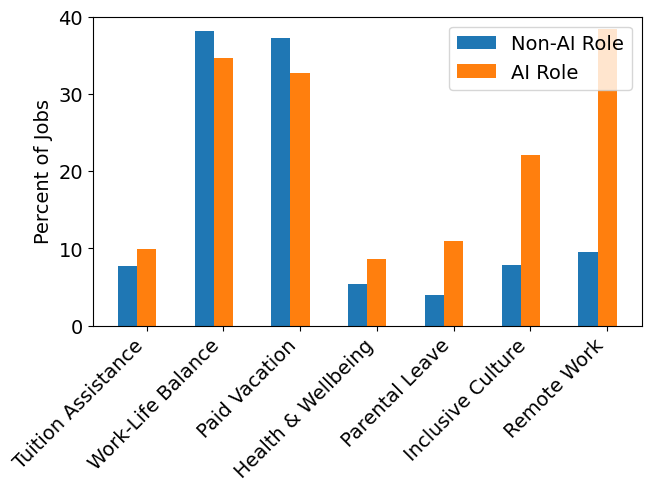

In [71]:
x = np.arange(len(benefits))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout = 'constrained')
for attribute, value in percentages.iterrows():
    ax.bar(x + width*multiplier, value, width, label=attribute)
    multiplier += 1
    
ax.set_ylabel('Percent of Jobs')
ax.set_xticks(x+width, benefits_labels, rotation=45, ha = 'right')
ax.set_ylim(0, 40)
ax.legend(loc = 'upper right', ncols = 2)

# change legend labels
ax.legend(['Non-AI Role', 'AI Role'])



## No Salary Sample

In [35]:
even_sample_nosal = pd.read_parquet('../data/small_samples/nosalary_sample_20k.parquet.gzip')

In [76]:

# Calculate percentages for each benefit by HAS_AI_SKILLS
percentages = even_sample_nosal.groupby('AI ROLE')[benefits].mean() * 100

In [77]:
percentages

,EDU_ASSISTANCE,WLB,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,wfh_wham
AI ROLE,,,,,,,
False,7.76,25.22,24.12,4.02,2.92,9.40,7.62
True,6.12,18.19,16.37,4.71,6.20,20.57,23.64


In [78]:
benefits_labels = "Tuition Assistance", "Work-Life Balance", "Paid Vacation", "Health & Wellbeing", "Parental Leave", "Inclusive Culture", "Remote Work"

In [79]:
len(benefits)

7

In [80]:
len(benefits_labels)

7

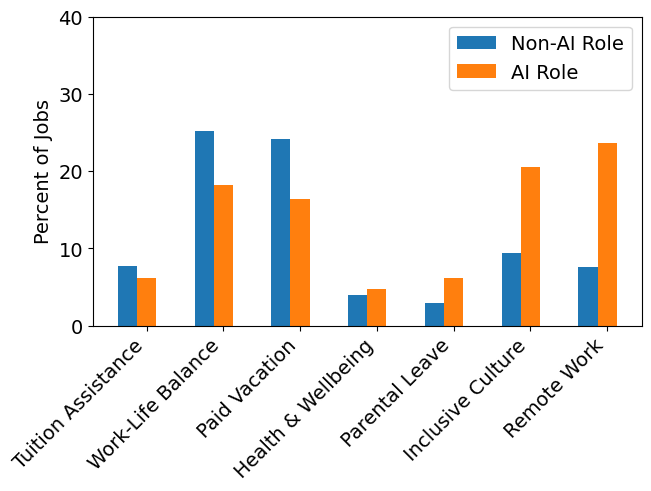

In [81]:
x = np.arange(len(benefits))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout = 'constrained')
for attribute, value in percentages.iterrows():
    ax.bar(x + width*multiplier, value, width, label=attribute)
    multiplier += 1
    
ax.set_ylabel('Percent of Jobs')
ax.set_xticks(x+width, benefits_labels, rotation=45, ha = 'right')
ax.set_ylim(0, 40)
ax.legend(loc = 'upper right', ncols = 2)

# change legend labels
ax.legend(['Non-AI Role', 'AI Role'])

